<a href="https://colab.research.google.com/github/luciestrada/Proyecto2_Biosenales_LucianaAcevedo_LucianaEstrada/blob/main/Proyecto2_biosenales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Consulta**

**Consultar qué índices del EEG, adicionales a los realizados en el proyecto 1 basados en
densidad espectral de potencia, mejoran la clasificación de estados en BCI. Citar las fuentes**

**Escoger por lo menos tres índices que se puedan implementar en Python, se pueden usar
librerías, explicar la medida y su uso en los datos del proyecto**

En el proyecto 1 utilizamos la densidad espectral de potencia (PSD) calculado con el método de Welch.

1.   **Varianza logarítmica CSP (Patrones Espaciles Comunes)**
Es una técnica de extracción de características ampliamente utilizada en problemas de clasificiación binaria, utiliza un filtrado espacial que transforma señales muticanal de EEG proyectándolas en una matriz de pesos óptimos. El funcionamiento matemático se basa en maximizar la varianza de la señal filtrada para una clase (por ejemplo la imaginación del movimiento de la mano derecha), mientras minimiza la varianza para la otra clase (mano izquierda). Una vez aplicados los filtros espaciales, se calcula la varianza de estas nuevas señales proyectadas y se le aplica una transformación logarítmica (Ramoser et al., 2000).

En otras palabras al aplicar CSP sobre los canales de interés de la corteza motora, el algoritmo aisla matemáticamente las fuentes subyacentes a los electrodos $C3$, $Cz$ y $C4$. Esto incrementa la distancia geométrica entre las clases en el espacio de características, facilitando la tarea del clasificador.

Para cosntruir las caracteríticas Log-Varianza, se calcula la varianza de cada señal z, se normaliza por la varianza total de todas las señales, y se aplica una transformada logarítimca.

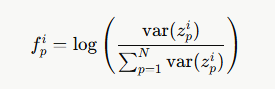




```
Libreria: mne.decoding
```
```

from mne.decoding import CSP
import numpy as np

# Suponiendo que 'epochs_data' tiene la forma (trials, canales, muestras)
# y 'labels' contiene las etiquetas de las clases (0 o 1)
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

# Entrena los filtros espaciales y extrae la varianza logarítmica de forma automática
X_csp = csp.fit_transform(epochs_data, labels)
# X_csp tendrá una dimensión de (trials, 4), listo para el clasificador
```

El vector de características final se construye  combinando las log-varianzas de todas las señales.




2. **Parámetros de Hjorth (dominio temporal)**

Son descriptores temporales calculados directamente sobre la señal sin transformada de Fourier, es decir,  aplicados directamente en el dominio del tiempo sobre señales univariadas (canal por canal).  Se basan en los momentos de la densidad espectral de potencia, calculados a través de la varianza de la señal original y sus derivadas sucesivas.

- **Actividad** = Representa la  varianza de de la amplitud de la señal(potencia).

$$\text{Actividad} = \sigma_x^2 = \text{Var}(x(t))$$

- **Movilidad**= Proporciona una estimación de la frecuencia media de la señal. Es la raíz de la varianza de la primera derivada dividida por la varianza de la señal.

$$\text{Movilidad} = \sqrt{\frac{\text{Var}(x'(t))}{\text{Var}(x(t))}}$$

- **Complejidad** = Indica qué tan similar es la señal a una onda senoidal pura. Es la movilidad de la derivada dividida por la movilidad de la señal.


$$\text{Complejidad} = \frac{\text{Movilidad}(x'(t))}{\text{Movilidad}(x(t))} = \sqrt{\frac{\text{Var}(x''(t))/\text{Var}(x'(t))}{\text{Var}(x'(t))/\text{Var}(x(t))}}$$



Durante el estado de reposo, las señales de la corteza motora muestran ondas rítmicas, suaves y sincronizadas (ritmo Mu/Alfa), lo que se traduce en una baja Movilidad y una Complejidad cercana a 1.  En BCI de MI, la complejidad tiende a ser mayor durante la imaginación que durante el movimiento real, , ya que el primero genera una señal más regular por retroalimentación propioceptiva.


```
Libreria: antropy o mne_features.univariate
```
```
import antropy as am
import numpy as np

# Se calcula sobre una matriz 'signal_epoch' de dimensiones (n_channels, n_times)
hjorth_features = []
for channel_data in signal_epoch:
    mobility, complexity = am.hjorth_params(channel_data)
    hjorth_features.extend([mobility, complexity])
# Retorna un vector con los índices de movilidad y complejidad por canal
```
Los parámetros de Hjorth capturan esta transición geométrica instantáneamente en cada época de análisis.  (Hjorth, 1970)

3. **Entropía de Permutación (PE)**

Es una métrica basada en la dinámica no lineal y la teoría de la información que cuantifica la complejidad, el desorden y la impredecibilidad de una serie temporal compleja. Su principal ventaja es que evalúa las relaciones ordinales entre los puntos de la señal, ignorando las amplitudes absolutas del voltaje. Específicamente, la PE mide la regularidad de la señal comparando el orden relativo de sus valores en ventanas deslizantes de longitud $m$ (orden de embedding). Tras determinar el patrón ordinal (permutación) de cada ventana, se calcula la entropía de Shannon de la distribución de dichos patrones mediante la ecuación:


$$PE = -\sum p(\pi) \cdot \log(p(\pi))$$

donde $\pi$ recorre las $m!$ permutaciones posibles. De este modo, una señal completamente regular (como una sinusoide perfecta) exhibe un $PE \approx 0$, mientras que una señal totalmente aleatoria alcanza la PE máxima (Bandt & Pompe, 2002)


Durante tareas de Imaginería Motora (MI), la desincronización cortical incrementa la irregularidad de la señal, elevando consecuentemente la PE.

La Entropía de Permutación actúa como una alternativa radical a la PSD porque es completamente inmune a los artefactos de parpadeo ocular (EOG) de gran amplitud o cambios repentinos de impedancia. Al evaluar las épocas del dataset, la PE cuantificará con alta precisión el incremento del caos combinatorio microestructural de la señal, provocado por la fragmentación del ritmo de reposo durante la activación motora (tanto imaginada como real). *De hecho, la literatura demuestra que la PE discrimina estados de reposo, MI y MR de mejor manera que la PSD en sujetos con baja relación señal-ruido (SNR) (Li et al., 2014)*.




```
Librería: antropy
```
```
import antropy as am

# Se recomienda fijar el orden (dimension) d=3, 4 o 5 y el delay delay=1
# signal_channel es un arreglo unidimensional (n_times,)
perm_entropy = am.permutation_entropy(signal_channel, order=3, delay=1, normalize=True)
```


En el contexto de los datos del proyecto, se aplica CSP de manera binaria por pares de condiciones: MR-D vs MR-I, y IM-D vs IM-I, utilizando los 6 canales seleccionados (C3, C4, FC3, FC4, CP3, CP4). Se seleccionan los primeros y últimos 3 componentes del vector propio (m=3, es decir 6 filtros espaciales), tal como recomienda la literatura. La log-varianza de estos componentes constituye el vector de características que se almacena en el dataframe junto con las métricas del proyecto 1.

**Implementación en Python:** Se puede implementar directamente utilizando la librería especializada en neurotecnología MNE-Python (mne.decoding.CSP) en combinación con scikit-learn.

# **Plan de análisis**

**Con la información recolectada, del entregable 1 y del punto anterior, proponer una
metodología de análisis que permita evidenciar la diferencia en ritmos cerebrales asociados
a las condiciones de: reposo, imaginación de movimiento mano derecha, imaginación de movimiento mano izquierda**



**Etapa 1: Carga y Preprocesamiento de los Datos**
La primera etapa corresponde a la carga y acondicionamiento de las señales bioeléctricas.
El pipeline de preprocesamiento es idéntico al implementado en el Proyecto 1 :

- Filtro Notch: Aplicado a 60 Hz para eliminar la interferencia de la red eléctrica.
- Filtro Pasa-Altas: A 1 Hz para remover la deriva de la línea base y frecuencias ultrabajas.
- Filtro Pasa-Bajas: A 40 Hz para limitar el ancho de banda a las frecuencias de interés cognitivo y descartar ruido muscular de alta frecuencia.
- Re-referenciación: Aplicación de Promedio Común (CAR) para reducir el ruido global de los electrodos y mejorar la Relación Señal-Ruido (SNR).
- Segmentación (Epoching): Extracción de épocas desde −1.0 hasta 4.5 segundos respecto al evento motor (pista visual en $t=0$), fijando la corrección de línea base (baseline) entre −1.0 y 0 segundos. Este procedimiento garantiza que las señales estén limpias y normalizadas antes de extraer características.

----

**Etapa 2: Extracción de Características Multidimensionales**

Se implementará una función unificada extraer_caracteristicas(epochs, canales) que calculará, para cada época y cada canal de interés de la corteza motora primaria (C3, C4, FC3, FC4, CP3, CP4), un conjunto de índices complementarios que cubren cuatro dimensiones independientes de la señal EEG:

- Dimensión Frecuencial (Proyecto 1): Se calcula la Densidad Espectral de Potencia (PSD) por bandas Mu (8–13 Hz) y Beta (13–30 Hz) mediante el método de Welch, el porcentaje de desincronización relacionada con el evento (ERD%), y el índice de lateralidad (LI) -
- Dimensión Espacial (Varianza Logarítmica CSP): Se aplica el algoritmo de Patrones Espaciales Comunes (CSP) de forma binaria directa para maximizar la diferencia entre las dos tareas activas (IM-D vs IM-I), seleccionando $m=3$ filtros extremos del vector propio (6 filtros espaciales en total). La log-varianza de las señales proyectadas constituye el vector de características espaciales, y las épocas de reposo se proyectan sobre este mismo espacio para evaluar su comportamiento basal
- Dimensión Temporal (Parámetros de Hjorth): Se calculan los tres descriptores de Hjorth —actividad, movilidad y complejidad—. Para evitar que la señal pierda poder discriminativo, estos parámetros se calcularán sobre la señal en banda ancha preprocesada (1–40 Hz), capturando los cambios geométricos rápidos inducidos por la desincronización neuronal de manera robusta ante la variabilidad inter-sujeto (Hjorth, 1970).
- Dimensión de Complejidad Dinámica: Se calcula la Entropía de Permutación (PE) con orden $m=4$ (longitud que cumple con la condición de estabilidad $N \gg m!$) y retraso $lag=1$ mediante la librería antropy. La PE cuantifica el grado de desorden en la microestructura temporal de la señal sin asumir estacionariedad, siendo ideal para épocas cortas (Bandt & Pompe, 2002).
----

**Etapa 3: Construcción del Dataframe Unificado**

Una rutina de procesamiento por lotes aplicará la función de extracción sobre todos los archivos de todos los sujetos del dataset. Los resultados se estructurarán y consolidarán en un único DataFrame con las columnas: Sujeto, Condicion (REST, IM-D, IM-I), Canal, Banda, Indice y Valor, permitiendo segmentar y consultar cualquier combinación de variables de forma directa.

---

**Etapa 4: Análisis Descriptivo y Estadístico Inferencial**

Para la visualización de datos se emplearán diagramas de caja (boxplots) y gráficos de violín (violinplots) para comparar las distribuciones entre las tres condiciones, junto con mapas de calor de p-valores para identificar los contrastes estadísticamente relevantes .
Dado que el diseño experimental es de medidas repetidas (los mismos sujetos participan en todas las tareas, generando datos correlacionados ), la selección de la prueba estadística inferencial seguirá un criterio estricto de distribución:

- Se aplicará la prueba de Shapiro-Wilk a cada variable para evaluar la normalidad.
- Si se rechaza la hipótesis de normalidad ($p < 0.05$), se utilizará la Prueba de Friedman (equivalente **no paramétrico** para medidas repetidas) para comparar las 3 condiciones, seguida de comparaciones post-hoc por pares mediante la Prueba de Rangos con Signos de Wilcoxon para muestras relacionadas, aplicando la corrección de Bonferroni ($\alpha_{\text{ajustado}} = 0.05 / 3 = 0.0166$).
- Si los datos no rechazan la normalidad, se empleará un ANOVA de Medidas Repetidas con la prueba post-hoc de Tukey.

---





# **Planteamiento de Hipótesis**

1. **Dimensión de Frecuencia (PSD en Banda μ)**

- $H_0$: No existen diferencias significativas en la potencia de la banda μ entre los canales C3 y C4 durante las IM-D.

- $H_1$: Existen diferencias significativas en la potencia de la banda μ entre los canales C3 y C4 durante IM-D.

*Existen diferencias significativas en la potencia de la banda Mu entre C3 y C4 durante IM-D, reflejando el control contralateral esperado.*

2. **Dimensión Temporal (Movilidad de Hjorth)**

- $H_0$: No existen diferencias significativas en el parámetro de Movilidad de Hjorth en el canal C3 al comparar el estado de reposo (REST) frente a IM-D.
- $H_2$: Existen diferencias significativas en el parámetro de Movilidad de Hjorth en el canal C3 al comparar el estado de reposo (REST) frente a IM-D.

*La Movilidad de Hjorth en C3 es significativamente diferente durante IM-D respecto a REST, evidenciando activación del hemisferio contralateral*

3. **Dimensión No-Lineal (Entropía de Permutación)**
- $H_0$: No existen diferencias significativas en la Entropía de Permutación en el canal C4 al comparar el estado de reposo (REST) frente a la imaginación de la mano izquierda (IM-I).
- $H_3$: Existen diferencias significativas en la Entropía de Permutación en el canal C4 al comparar el estado de reposo (REST) frente a la imaginación de la mano izquierda (IM-I).

*Evaluar la Entropía de Permutación en C4 durante la condición de mano izquierda permite ver si el caos de la señal cambia en el lugar correcto del cerebro.*

*La Entropía de Permutación en C4 es significativamente diferente durante IM-I respecto a REST, reflejando mayor complejidad dinámica en el hemisferio contralateral a la mano imaginada*

4. **Dimensión Espacial (Filtro CSP)**
- $H_0$: No existen diferencias significativas en los valores de log-varianza del primer componente espacial (CSP) entre IM-D y e IM-I.
- $H_4$: Existen diferencias significativas en los valores de log-varianza del primer componente espacial (CSP) entre IM-D y e IM-I.

*La log-varianza del primer componente CSP difiere significativamente entre IM-D e IM-I, demostrando que el filtro espacial separa ambas condiciones de lateralidad*

5. **Dimensión de Clasificación (Rendimiento BCI)**
- $H_0$: El accuracy global del clasificador supervisado entrenado con las características avanzadas es igual o menor al nivel de azar teórico del 33.3%.
- $H_5$: El accuracy global del clasificador supervisado entrenado con las características avanzadas es significativamente superior al nivel de azar teórico del 33.3%.




# CÓDIGO

In [1]:
!pip install openneuro-py mne-bids

In [2]:
!pip install -q mne antropy

In [3]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mne
import antropy as ant

from google.colab import drive
from scipy import signal as sci_signal
from scipy.signal import sosfiltfilt, butter
from scipy.integrate import trapezoid
from scipy import stats
from mne.decoding import CSP

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')
print("Imports listos.")

Imports listos.


In [4]:
drive.mount('/content/drive')

RUTA_DRIVE = '/content/drive/MyDrive/Proyecto_BCI_2026'
os.makedirs(RUTA_DRIVE, exist_ok=True)

SUJETOS        = ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005']
RUNS_DESCARGAR = range(1, 9)
EXTENSIONES    = ['_eeg.set', '_events.tsv', '_channels.tsv', '_eeg.json']
BASE_URL       = "https://openneuro.org/crn/datasets/ds004362/files"

def descargar_archivo(url, destino):
    if os.path.exists(destino) and os.path.getsize(destino) > 0:
        return "ya existe"
    os.makedirs(os.path.dirname(destino), exist_ok=True)
    try:
        urllib.request.urlretrieve(url, destino)
        return "ok"
    except Exception as e:
        return f"error: {e}"

print("Descargando datos...\n")
for sub in SUJETOS:
    print(f"  {sub}...")
    for run in RUNS_DESCARGAR:
        for ext in EXTENSIONES:
            nombre  = f"{sub}_task-motion_run-{run}{ext}"
            url     = f"{BASE_URL}/{sub}:eeg:{nombre}"
            destino = os.path.join(RUTA_DRIVE, sub, 'eeg', nombre)
            estado  = descargar_archivo(url, destino)
            if estado not in ("ya existe", "ok"):
                print(f"    {nombre}: {estado}")
    sets = [f for f in os.listdir(os.path.join(RUTA_DRIVE, sub, 'eeg'))
            if f.endswith('.set')]
    print(f"    {len(sets)} archivos .set")

print("\nDescarga completa.")

Mounted at /content/drive
Descargando datos...

  sub-001...
    8 archivos .set
  sub-002...
    8 archivos .set
  sub-003...
    8 archivos .set
  sub-004...
    8 archivos .set
  sub-005...
    8 archivos .set

Descarga completa.


Cargae de archivos

In [5]:
RUNS_INTERES    = [3, 4, 7, 8]
CANALES_INTERES = ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4']

datos = {}

for sub in SUJETOS:
    print(f"\nCargando {sub}...")
    datos[sub] = {}

    for run_num in RUNS_INTERES:
        ruta_set = os.path.join(RUTA_DRIVE, sub, 'eeg',
                                f"{sub}_task-motion_run-{run_num}_eeg.set")
        ruta_ev  = os.path.join(RUTA_DRIVE, sub, 'eeg',
                                f"{sub}_task-motion_run-{run_num}_events.tsv")

        if not os.path.exists(ruta_set):
            print(f"  run-{run_num}: no encontrado")
            continue

        raw = mne.io.read_raw_eeglab(ruta_set, preload=True, verbose=False)
        disponibles = [c for c in CANALES_INTERES if c in raw.ch_names]
        raw.pick(disponibles)
        df_ev = pd.read_csv(ruta_ev, sep='\t')

        datos[sub][run_num] = {'raw': raw, 'events': df_ev}
        print(f"  run-{run_num}: OK | canales: {raw.ch_names} | eventos: {len(df_ev)}")

print("\nCarga completa.")


Cargando sub-001...
  run-3: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-4: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-7: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-8: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30

Cargando sub-002...
  run-3: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-4: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-7: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-8: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30

Cargando sub-003...
  run-3: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-4: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-7: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-8: OK |

Preprocesamiento (idéntico al Proyecto 1)

In [6]:
def preprocesar_raw(raw):
    raw = raw.copy()
    raw.filter(l_freq=1.0, h_freq=None, method='iir',
               iir_params=dict(order=4, ftype='butter'),
               phase='zero', verbose=False)
    raw.filter(l_freq=None, h_freq=40.0, method='iir',
               iir_params=dict(order=4, ftype='butter'),
               phase='zero', verbose=False)
    raw.notch_filter(freqs=60.0, method='iir',
                     iir_params=dict(order=2, ftype='butter'),
                     verbose=False)
    raw.set_eeg_reference('average', projection=False, verbose=False)
    return raw

for sub in SUJETOS:
    for run_num in datos[sub]:
        datos[sub][run_num]['raw'] = preprocesar_raw(datos[sub][run_num]['raw'])
    print(f"{sub}: preprocesado")

print("\nPreprocesamiento completo.")

sub-001: preprocesado
sub-002: preprocesado
sub-003: preprocesado
sub-004: preprocesado
sub-005: preprocesado

Preprocesamiento completo.


Segmentación en épocas (idéntico al Proyecto 1)

In [7]:
T_MIN, T_MAX = -1.0, 4.5
BASELINE     = (-1.0, 0.0)

EVENTOS = {
    'TASK1T2': ('MR-D', 1), 'TASK1T1': ('MR-I', 2),
    'TASK2T2': ('IM-D', 3), 'TASK2T1': ('IM-I', 4),
    'TASK1T0': ('REST', 5), 'TASK2T0': ('REST', 5),
}

def segmentar_run(raw, df_events):
    sfreq = raw.info['sfreq']
    df_events['value'] = df_events['value'].astype(str).str.strip()
    df_filt = df_events[df_events['value'].isin(EVENTOS)].copy()
    if df_filt.empty:
        return {}
    samples  = (df_filt['onset'].values * sfreq).astype(int)
    ev_ids   = np.array([EVENTOS[v][1] for v in df_filt['value']])
    ev_array = np.column_stack([samples, np.zeros(len(samples), int), ev_ids])
    ev_dict  = {EVENTOS[v][0]: EVENTOS[v][1] for v in df_filt['value'].unique()}
    epochs   = mne.Epochs(raw, ev_array, event_id=ev_dict,
                          tmin=T_MIN, tmax=T_MAX, baseline=BASELINE,
                          reject=None, preload=True, verbose=False)
    return {cond: epochs[cond] for cond in ev_dict
            if cond in epochs.event_id and len(epochs[cond]) > 0}

epocas = {}
for sub in SUJETOS:
    print(f"\nSegmentando {sub}...")
    acumulado = {c: [] for c in ['MR-D', 'MR-I', 'IM-D', 'IM-I', 'REST']}
    for run_num, contenido in datos[sub].items():
        for cond, ep in segmentar_run(contenido['raw'], contenido['events']).items():
            if cond in acumulado:
                acumulado[cond].append(ep)
    epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
                   for c, l in acumulado.items()}
    for cond, ep in epocas[sub].items():
        n = len(ep) if ep is not None else 0
        print(f"  {cond}: {n} épocas")

print("\nSegmentación completa.")


Segmentando sub-001...
  MR-D: 14 épocas
  MR-I: 16 épocas
  IM-D: 14 épocas
  IM-I: 16 épocas
  REST: 56 épocas

Segmentando sub-002...
  MR-D: 14 épocas
  MR-I: 14 épocas
  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-003...
  MR-D: 15 épocas
  MR-I: 15 épocas
  IM-D: 15 épocas
  IM-I: 15 épocas
  REST: 56 épocas

Segmentando sub-004...
  MR-D: 14 épocas
  MR-I: 14 épocas
  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-005...
  MR-D: 14 épocas
  MR-I: 14 épocas
  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentación completa.


**Funciones de los índices nuevo**

In [8]:
# ── Utilidades ───────────────────────────────────────────────

def butter_bandpass(sfreq, fmin, fmax, order=4):
    nyq  = sfreq / 2.0
    low  = max(fmin / nyq, 1e-4)
    high = min(fmax / nyq, 1 - 1e-4)
    return butter(order, [low, high], btype='band', output='sos')


def hjorth(signal):
    """Actividad, movilidad y complejidad de Hjorth para señal 1D."""
    var_sig = np.var(signal)
    if var_sig == 0:
        return 0.0, 0.0, 0.0
    d1     = np.diff(signal)
    var_d1 = np.var(d1)
    mob    = np.sqrt(var_d1 / var_sig)
    d2     = np.diff(d1)
    var_d2 = np.var(d2)
    mob_d1 = np.sqrt(var_d2 / var_d1) if var_d1 > 0 else 0.0
    comp   = mob_d1 / mob if mob > 0 else 0.0
    return float(var_sig), float(mob), float(comp)


def perm_entropy(signal, order=4, lag=1):
    """Entropía de permutación normalizada."""
    try:
        return float(ant.perm_entropy(signal, order=order,
                                       delay=lag, normalize=True))
    except Exception:
        return np.nan


print("Funciones de índices nuevos definidas.")

Funciones de índices nuevos definidas.


Función de extracción completa (PSD del proyecto 1 + índices nuevos)

In [9]:
BANDAS = {
    'delta':    (1,  4),
    'theta':    (4,  8),
    'mu':       (8, 13),
    'beta':     (13, 30),
    'beta_alto':(20, 30),
}

T_BASELINE = (-1.0, 0.0)
T_ACTIVO   = (0.5,  3.5)
T_PMBR     = (4.0,  4.5)

def pot_banda(data_1d, fmin, fmax, sfreq):
    """Potencia en banda por Welch con parámetros adaptativos (igual que P1)."""
    n            = len(data_1d)
    nperseg      = min(256, n)
    noverlap     = min(128, nperseg // 2)
    freqs, psd   = sci_signal.welch(data_1d, fs=sfreq,
                                     nperseg=nperseg, noverlap=noverlap)
    idx = (freqs >= fmin) & (freqs <= fmax)
    return trapezoid(psd[idx], x=freqs[idx])


def calcular_metricas(epoch_data, times, sfreq, ch_names):
    """
    Calcula todas las métricas para una época:
    - PSD por banda y canal (igual que P1)
    - ERD%, PMBR%, LI (igual que P1)
    - Hjorth actividad, movilidad, complejidad (NUEVO P2)
    - Entropía de permutación mu y beta (NUEVO P2)
    """

    def segmento(t_ini, t_fin):
        idx = (times >= t_ini) & (times <= t_fin)
        return epoch_data[:, idx]

    seg_base = segmento(*T_BASELINE)
    seg_act  = segmento(*T_ACTIVO)
    seg_pmbr = segmento(*T_PMBR)

    metricas = {}

    # ── PSD todas las bandas (P1) ────────────────────────────
    for banda, (fmin, fmax) in BANDAS.items():
        for i, canal in enumerate(ch_names):
            metricas[f'psd_{banda}_{canal}'] = pot_banda(
                epoch_data[i], fmin, fmax, sfreq)

    # ── ERD%, PMBR%, LI (P1) ────────────────────────────────
    for canal in ['C3', 'C4']:
        if canal not in ch_names:
            continue
        i = ch_names.index(canal)
        for banda, (fmin, fmax) in [('mu', (8, 13)), ('beta', (13, 30))]:
            pb = pot_banda(seg_base[i], fmin, fmax, sfreq)
            pa = pot_banda(seg_act[i],  fmin, fmax, sfreq)
            metricas[f'erd_{banda}_{canal}'] = ((pa - pb) / (pb + 1e-12)) * 100
        pb_b = pot_banda(seg_base[i], 13, 30, sfreq)
        pp_b = pot_banda(seg_pmbr[i], 13, 30, sfreq)
        metricas[f'pmbr_beta_{canal}'] = ((pp_b - pb_b) / (pb_b + 1e-12)) * 100

    if 'C3' in ch_names and 'C4' in ch_names:
        ic3, ic4 = ch_names.index('C3'), ch_names.index('C4')
        for banda, (fmin, fmax) in [('mu', (8, 13)), ('beta', (13, 30))]:
            p3 = pot_banda(epoch_data[ic3], fmin, fmax, sfreq)
            p4 = pot_banda(epoch_data[ic4], fmin, fmax, sfreq)
            metricas[f'LI_{banda}'] = (p3 - p4) / (p3 + p4 + 1e-12)

    # ── HJORTH sobre banda ancha (señal ya filtrada 1–40 Hz) ─
    for i, canal in enumerate(ch_names):
        sig = seg_act[i]
        act, mob, comp = hjorth(sig)
        metricas[f'hjorth_act_{canal}']  = act
        metricas[f'hjorth_mob_{canal}']  = mob
        metricas[f'hjorth_comp_{canal}'] = comp

    # ── ENTROPÍA DE PERMUTACIÓN en mu y beta ────────────────
    for i, canal in enumerate(ch_names):
        sig = seg_act[i]
        for banda, (fmin, fmax) in [('mu', (8, 13)), ('beta', (13, 30))]:
            sos      = butter_bandpass(sfreq, fmin, fmax)
            sig_filt = sosfiltfilt(sos, sig)
            pe       = perm_entropy(sig_filt, order=4, lag=1)
            metricas[f'pe_{banda}_{canal}'] = pe

    return metricas


print("calcular_metricas() definida.")

calcular_metricas() definida.


Construcción del dataframe

In [10]:
registros = []

for sub in SUJETOS:
    for cond in ['MR-D', 'MR-I', 'IM-D', 'IM-I', 'REST']:
        if cond not in epocas[sub] or epocas[sub][cond] is None:
            continue
        ep       = epocas[sub][cond]
        times    = ep.times
        sfreq    = ep.info['sfreq']
        ch_names = ep.ch_names

        for trial_idx in range(len(ep)):
            try:
                data = ep[trial_idx].get_data(copy=False)[0]
                met  = calcular_metricas(data, times, sfreq, ch_names)
                met['sujeto']    = sub
                met['condicion'] = cond
                met['trial']     = trial_idx
                registros.append(met)
            except Exception as e:
                print(f"  Error {sub} {cond} trial {trial_idx}: {e}")

df_final = pd.DataFrame(registros)

cols_id    = ['sujeto', 'condicion', 'trial']
cols_resto = [c for c in df_final.columns if c not in cols_id]
df_final   = df_final[cols_id + cols_resto]

print(f"DataFrame: {df_final.shape[0]} filas × {df_final.shape[1]} columnas")
display(df_final.head())

DataFrame: 568 filas × 81 columnas


,sujeto,condicion,trial,psd_delta_C3,psd_delta_C4,psd_delta_Cz,psd_delta_Fc3,psd_delta_Fc4,psd_delta_Cp3,psd_delta_Cp4,...,pe_mu_Cz,pe_beta_Cz,pe_mu_Fc3,pe_beta_Fc3,pe_mu_Fc4,pe_beta_Fc4,pe_mu_Cp3,pe_beta_Cp3,pe_mu_Cp4,pe_beta_Cp4
0,sub-001,MR-D,0,1.818715e-11,2.504329e-11,5.273335e-11,7.992348e-11,4.171096e-11,2.431371e-11,4.325976e-11,...,0.521698,0.706478,0.520457,0.719715,0.530977,0.717770,0.516883,0.717817,0.505987,0.688715
1,sub-001,MR-D,1,4.260277e-11,4.038305e-11,4.912322e-11,1.209554e-10,9.786971e-11,6.006016e-11,9.077169e-11,...,0.535636,0.729795,0.510139,0.723510,0.529124,0.692619,0.523820,0.711357,0.521330,0.711736
2,sub-001,MR-D,2,3.604830e-11,2.866266e-11,2.961265e-11,7.501609e-11,1.221808e-10,8.711992e-11,3.916383e-11,...,0.522551,0.680965,0.497605,0.709879,0.530452,0.721070,0.524525,0.712010,0.517072,0.701520
3,sub-001,MR-D,3,4.409885e-11,5.141148e-11,4.291148e-11,1.680582e-10,4.654256e-11,4.381740e-11,9.392301e-11,...,0.530910,0.726261,0.530196,0.723957,0.528811,0.728544,0.524030,0.723899,0.539396,0.705671
4,sub-001,MR-D,4,2.887477e-11,5.149500e-11,3.061057e-11,8.016608e-11,8.782192e-11,5.485374e-11,4.137261e-11,...,0.530392,0.719411,0.522695,0.705970,0.533994,0.707397,0.533264,0.696990,0.533687,0.695094


`CSP log-varianza`

In [11]:
# CSP se calcula a nivel de sujeto, no de época individual.
# Se agrega como columnas CSP_1 ... CSP_6 al df_final
# solo para las condiciones IM-D e IM-I.

CANALES_CSP = ['C3', 'C4', 'Fc3', 'Fc4', 'Cp3', 'Cp4']
N_COMP_CSP  = 6

csp_registros = []

for sub in SUJETOS:
    ep_imd = epocas[sub].get('IM-D')
    ep_imi = epocas[sub].get('IM-I')

    if ep_imd is None or ep_imi is None:
        print(f"{sub}: falta IM-D o IM-I, saltando CSP.")
        continue

    chs   = [c for c in CANALES_CSP
             if c in ep_imd.ch_names and c in ep_imi.ch_names]
    X_imd = ep_imd.copy().pick_channels(chs, ordered=True).get_data()
    X_imi = ep_imi.copy().pick_channels(chs, ordered=True).get_data()

    X = np.concatenate([X_imd, X_imi], axis=0)
    y = np.array([0] * len(X_imd) + [1] * len(X_imi))

    csp = CSP(n_components=N_COMP_CSP, reg=None, log=True, norm_trace=False)
    try:
        csp.fit(X, y)
    except Exception as e:
        print(f"{sub}: error CSP: {e}")
        continue

    for ep_data, cond in [(X_imd, 'IM-D'), (X_imi, 'IM-I')]:
        logvar = csp.transform(ep_data)   # (n_epocas, 6)
        for trial_idx in range(len(ep_data)):
            fila = {'sujeto': sub, 'condicion': cond, 'trial': trial_idx}
            for comp in range(N_COMP_CSP):
                fila[f'CSP_{comp+1}'] = float(logvar[trial_idx, comp])
            csp_registros.append(fila)

    print(f"{sub}: CSP calculado ({len(X_imd)} IM-D, {len(X_imi)} IM-I épocas)")

df_csp = pd.DataFrame(csp_registros)

# Merge con df_final
df_final = df_final.merge(df_csp, on=['sujeto', 'condicion', 'trial'], how='left')

print(f"\nDataFrame con CSP: {df_final.shape[0]} filas × {df_final.shape[1]} columnas")
print(f"Columnas CSP: {[c for c in df_final.columns if c.startswith('CSP_')]}")

sub-001: CSP calculado (14 IM-D, 16 IM-I épocas)
sub-002: CSP calculado (14 IM-D, 14 IM-I épocas)
sub-003: CSP calculado (15 IM-D, 15 IM-I épocas)
sub-004: CSP calculado (14 IM-D, 14 IM-I épocas)
sub-005: CSP calculado (14 IM-D, 14 IM-I épocas)

DataFrame con CSP: 568 filas × 87 columnas
Columnas CSP: ['CSP_1', 'CSP_2', 'CSP_3', 'CSP_4', 'CSP_5', 'CSP_6']


análisis descriptivo (gráficas) y análisis estadístico (hipótesis).

In [12]:
# Configuración visual
ALPHA  = 0.05
COLORES = {
    'MR-D': '#2196F3', 'MR-I': '#4CAF50',
    'IM-D': '#FF9800', 'IM-I': '#9C27B0',
    'REST': '#9E9E9E'
}
CONDS_ACTIVAS = ['IM-D', 'IM-I', 'REST']   # las 3 condiciones del P2

print("Configuración lista.")

Configuración lista.


 Análisis descriptivo: Hjorth

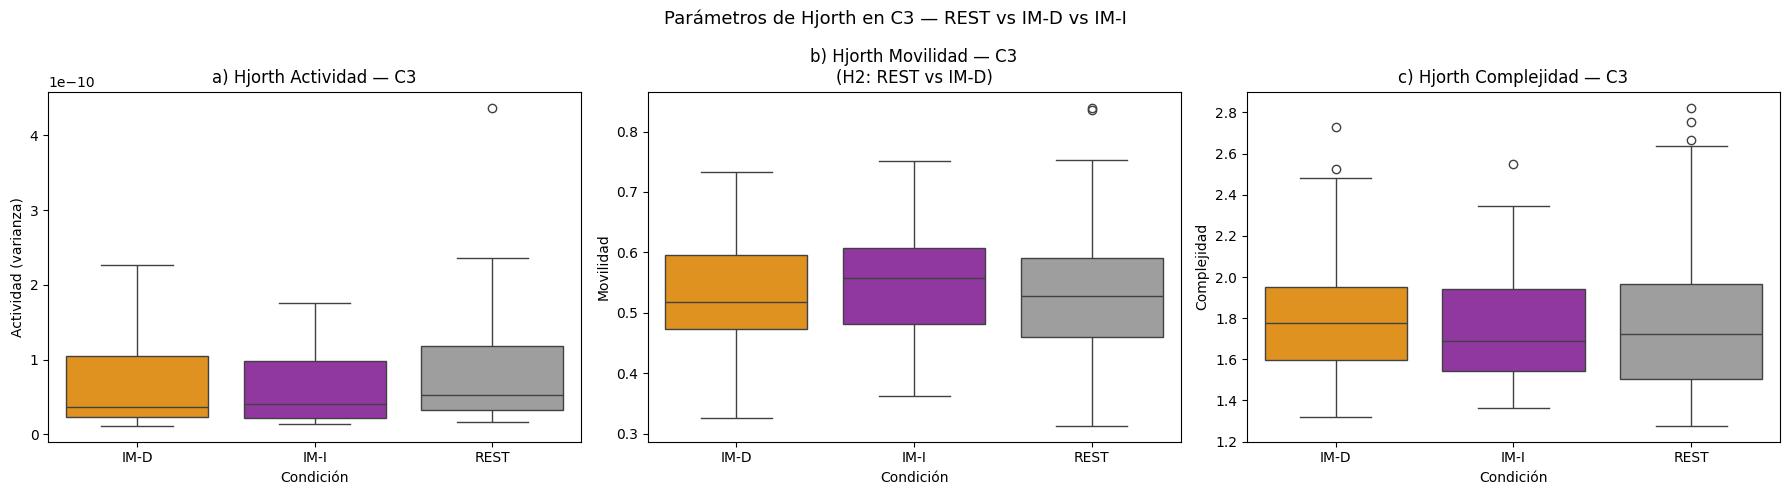

In [13]:
# ============================================================
# GRÁFICA 1 — Parámetros de Hjorth por condición
# Hipótesis H2 (movilidad C3) y H5 (complejidad MR vs IM)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_act = df_final[df_final['condicion'].isin(CONDS_ACTIVAS)]

# a) Actividad en C3
sns.boxplot(data=df_act, x='condicion', y='hjorth_act_C3',
            hue='condicion', palette=COLORES, legend=False, ax=axes[0])
axes[0].set_title('a) Hjorth Actividad — C3')
axes[0].set_ylabel('Actividad (varianza)')
axes[0].set_xlabel('Condición')

# b) Movilidad en C3  ← clave para H2
sns.boxplot(data=df_act, x='condicion', y='hjorth_mob_C3',
            hue='condicion', palette=COLORES, legend=False, ax=axes[1])
axes[1].set_title('b) Hjorth Movilidad — C3\n(H2: REST vs IM-D)')
axes[1].set_ylabel('Movilidad')
axes[1].set_xlabel('Condición')

# c) Complejidad en C3
sns.boxplot(data=df_act, x='condicion', y='hjorth_comp_C3',
            hue='condicion', palette=COLORES, legend=False, ax=axes[2])
axes[2].set_title('c) Hjorth Complejidad — C3')
axes[2].set_ylabel('Complejidad')
axes[2].set_xlabel('Condición')

plt.suptitle('Parámetros de Hjorth en C3 — REST vs IM-D vs IM-I', fontsize=13)
plt.tight_layout()
plt.savefig('hjorth_descriptivo.png', dpi=150)
plt.show()

 Análisis descriptivo: Entropía de permutación

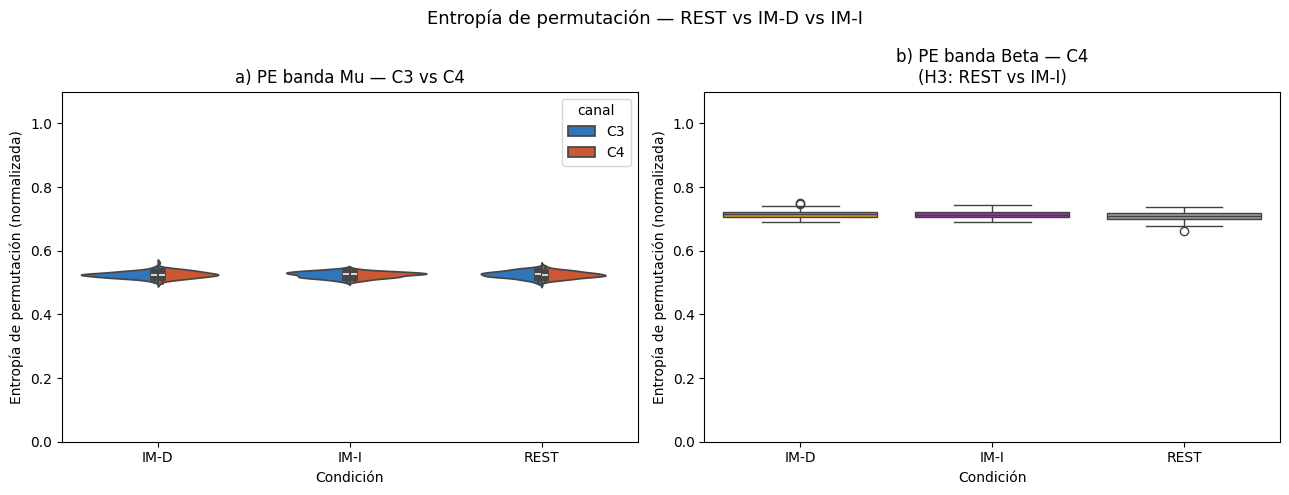

In [14]:
# ============================================================
# GRÁFICA 2 — Entropía de permutación por condición
# Hipótesis H3 (PE en C4, REST vs IM-I)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# a) PE banda mu en C3 y C4
df_pe_c3 = df_act[['condicion', 'pe_mu_C3']].copy()
df_pe_c3['canal'] = 'C3'
df_pe_c3 = df_pe_c3.rename(columns={'pe_mu_C3': 'PE_mu'})

df_pe_c4 = df_act[['condicion', 'pe_mu_C4']].copy()
df_pe_c4['canal'] = 'C4'
df_pe_c4 = df_pe_c4.rename(columns={'pe_mu_C4': 'PE_mu'})

df_pe_long = pd.concat([df_pe_c3, df_pe_c4], ignore_index=True)

sns.violinplot(data=df_pe_long, x='condicion', y='PE_mu',
               hue='canal', split=True,
               palette=['#1976D2', '#E64A19'],
               inner='box', ax=axes[0])
axes[0].set_title('a) PE banda Mu — C3 vs C4')
axes[0].set_ylabel('Entropía de permutación (normalizada)')
axes[0].set_xlabel('Condición')
axes[0].set_ylim(0, 1.1)

# b) PE banda beta en C4  ← canal contralateral mano izquierda
sns.boxplot(data=df_act, x='condicion', y='pe_beta_C4',
            hue='condicion', palette=COLORES, legend=False, ax=axes[1])
axes[1].set_title('b) PE banda Beta — C4\n(H3: REST vs IM-I)')
axes[1].set_ylabel('Entropía de permutación (normalizada)')
axes[1].set_xlabel('Condición')
axes[1].set_ylim(0, 1.1)

plt.suptitle('Entropía de permutación — REST vs IM-D vs IM-I', fontsize=13)
plt.tight_layout()
plt.savefig('pe_descriptivo.png', dpi=150)
plt.show()

Análisis descriptivo: PSD banda Mu en C3 vs C4

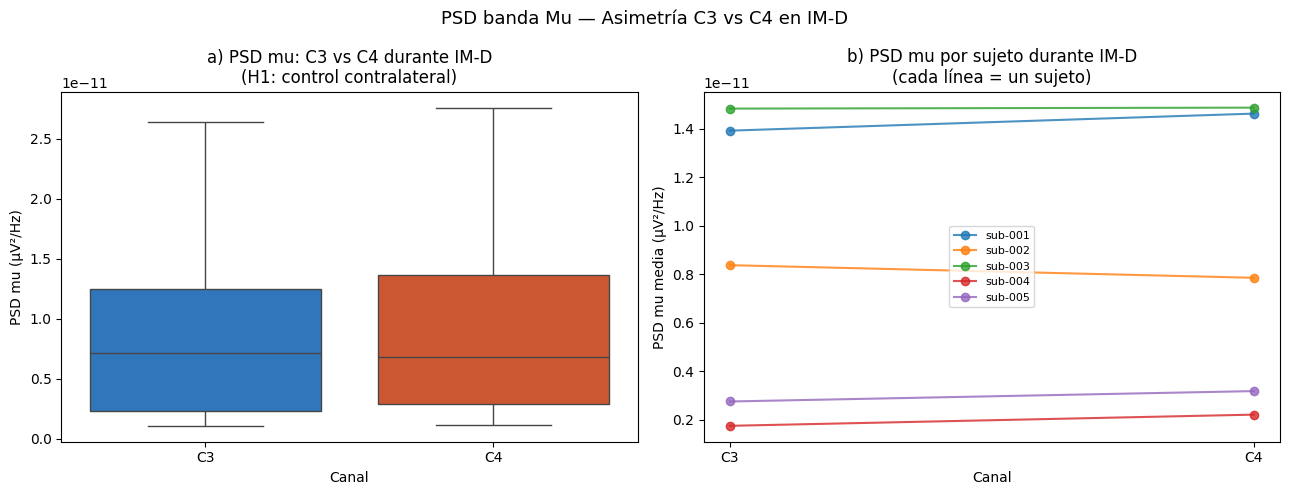

In [15]:
# ============================================================
# GRÁFICA 3 — PSD mu C3 vs C4 dentro de IM-D
# Hipótesis H1 (control contralateral)
# ============================================================

df_imd = df_final[df_final['condicion'] == 'IM-D'].copy()

df_psd_c3 = df_imd[['trial', 'sujeto', 'psd_mu_C3']].rename(
    columns={'psd_mu_C3': 'PSD_mu'})
df_psd_c3['canal'] = 'C3'

df_psd_c4 = df_imd[['trial', 'sujeto', 'psd_mu_C4']].rename(
    columns={'psd_mu_C4': 'PSD_mu'})
df_psd_c4['canal'] = 'C4'

df_psd_long = pd.concat([df_psd_c3, df_psd_c4], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_psd_long, x='canal', y='PSD_mu',
            hue='canal', palette=['#1976D2', '#E64A19'],
            legend=False, ax=axes[0])
axes[0].set_title('a) PSD mu: C3 vs C4 durante IM-D\n(H1: control contralateral)')
axes[0].set_ylabel('PSD mu (µV²/Hz)')
axes[0].set_xlabel('Canal')

# Scatter: C3 vs C4 por sujeto para ver lateralización individual
medias_sub = df_imd.groupby('sujeto')[['psd_mu_C3', 'psd_mu_C4']].mean()
for sub in medias_sub.index:
    axes[1].plot(['C3', 'C4'],
                 [medias_sub.loc[sub, 'psd_mu_C3'],
                  medias_sub.loc[sub, 'psd_mu_C4']],
                 'o-', alpha=0.8, label=sub)
axes[1].set_title('b) PSD mu por sujeto durante IM-D\n(cada línea = un sujeto)')
axes[1].set_ylabel('PSD mu media (µV²/Hz)')
axes[1].set_xlabel('Canal')
axes[1].legend(fontsize=8)

plt.suptitle('PSD banda Mu — Asimetría C3 vs C4 en IM-D', fontsize=13)
plt.tight_layout()
plt.savefig('psd_mu_c3_c4.png', dpi=150)
plt.show()

 Análisis descriptivo: CSP log-varianza

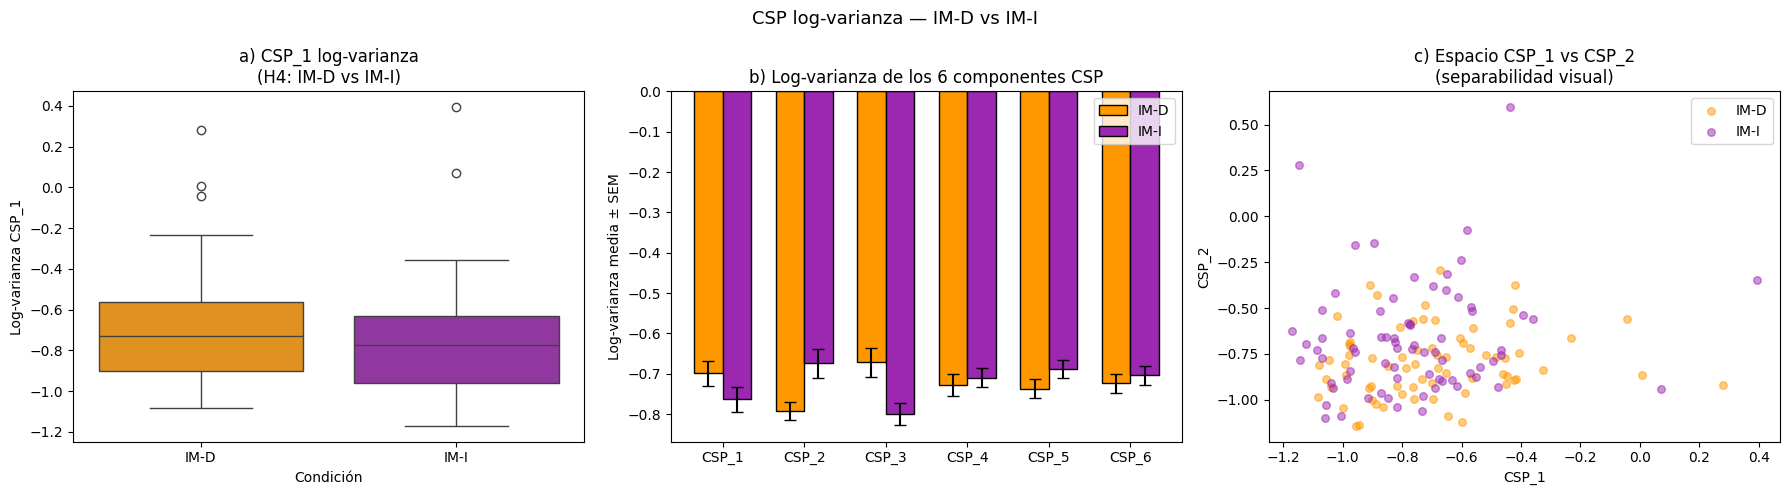

In [16]:
# ============================================================
# GRÁFICA 4 — CSP log-varianza: IM-D vs IM-I
# Hipótesis H4 (CSP_1 discrimina lateralidad)
# ============================================================

df_csp_plot = df_final[df_final['condicion'].isin(['IM-D', 'IM-I'])].copy()
df_csp_plot = df_csp_plot.dropna(subset=['CSP_1'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Boxplot CSP_1 — el componente más discriminativo
sns.boxplot(data=df_csp_plot, x='condicion', y='CSP_1',
            hue='condicion',
            palette={'IM-D': COLORES['IM-D'], 'IM-I': COLORES['IM-I']},
            legend=False, ax=axes[0])
axes[0].set_title('a) CSP_1 log-varianza\n(H4: IM-D vs IM-I)')
axes[0].set_ylabel('Log-varianza CSP_1')
axes[0].set_xlabel('Condición')

# b) Todos los componentes CSP como barplot de medias
csp_cols = [f'CSP_{i}' for i in range(1, 7)
            if f'CSP_{i}' in df_csp_plot.columns]
medias_imd = df_csp_plot[df_csp_plot['condicion'] == 'IM-D'][csp_cols].mean()
medias_imi = df_csp_plot[df_csp_plot['condicion'] == 'IM-I'][csp_cols].mean()
sems_imd   = df_csp_plot[df_csp_plot['condicion'] == 'IM-D'][csp_cols].sem()
sems_imi   = df_csp_plot[df_csp_plot['condicion'] == 'IM-I'][csp_cols].sem()

x = np.arange(len(csp_cols))
w = 0.35
axes[1].bar(x - w/2, medias_imd, w, yerr=sems_imd,
            color=COLORES['IM-D'], capsize=4,
            edgecolor='black', label='IM-D')
axes[1].bar(x + w/2, medias_imi, w, yerr=sems_imi,
            color=COLORES['IM-I'], capsize=4,
            edgecolor='black', label='IM-I')
axes[1].set_xticks(x)
axes[1].set_xticklabels(csp_cols)
axes[1].set_title('b) Log-varianza de los 6 componentes CSP')
axes[1].set_ylabel('Log-varianza media ± SEM')
axes[1].legend()

# c) Scatter CSP_1 vs CSP_2 coloreado por condición
for cond in ['IM-D', 'IM-I']:
    sub_df = df_csp_plot[df_csp_plot['condicion'] == cond]
    if 'CSP_2' in sub_df.columns:
        axes[2].scatter(sub_df['CSP_1'], sub_df['CSP_2'],
                        color=COLORES[cond], alpha=0.5,
                        label=cond, s=30)
axes[2].set_title('c) Espacio CSP_1 vs CSP_2\n(separabilidad visual)')
axes[2].set_xlabel('CSP_1')
axes[2].set_ylabel('CSP_2')
axes[2].legend()

plt.suptitle('CSP log-varianza — IM-D vs IM-I', fontsize=13)
plt.tight_layout()
plt.savefig('csp_descriptivo.png', dpi=150)
plt.show()

Heatmap descriptivo de todas las métricas

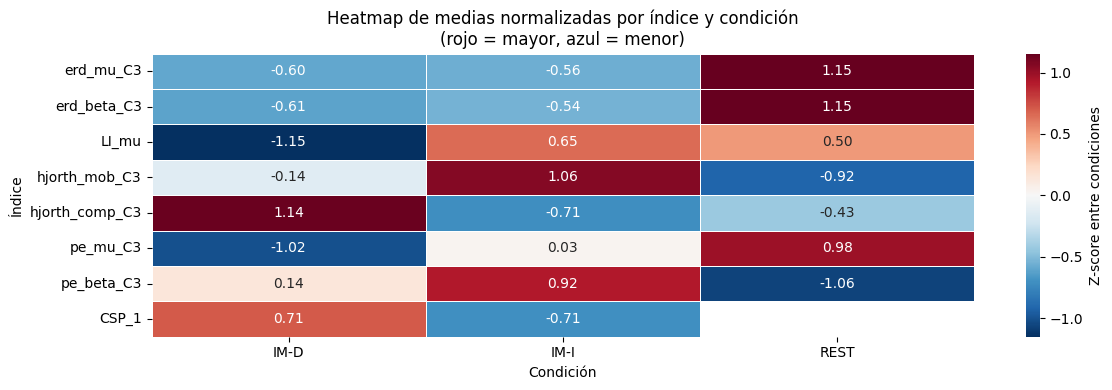

In [17]:
# ============================================================
# GRÁFICA 5 — Heatmap de medias normalizadas
# Vista global de todos los índices por condición
# ============================================================

vars_resumen = [
    'erd_mu_C3', 'erd_beta_C3',
    'LI_mu',
    'hjorth_mob_C3', 'hjorth_comp_C3',
    'pe_mu_C3', 'pe_beta_C3',
    'CSP_1'
]
vars_ok = [v for v in vars_resumen if v in df_final.columns]

medias = (df_final[df_final['condicion'].isin(CONDS_ACTIVAS)]
          .groupby('condicion')[vars_ok]
          .mean())

# Normalizar por z-score entre condiciones para comparar escalas distintas
medias_norm = (medias - medias.mean()) / (medias.std() + 1e-12)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(medias_norm.T, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Z-score entre condiciones'})
ax.set_title('Heatmap de medias normalizadas por índice y condición\n'
             '(rojo = mayor, azul = menor)', fontsize=12)
ax.set_xlabel('Condición')
ax.set_ylabel('Índice')
plt.tight_layout()
plt.savefig('heatmap_descriptivo.png', dpi=150)
plt.show()

Shapiro-Wilk para todos los índices

In [18]:
# ============================================================
# ESTADÍSTICA — PASO 1: NORMALIDAD (Shapiro-Wilk)
# ============================================================

from scipy import stats
from itertools import combinations

VARS_STAT = [
    'psd_mu_C3', 'psd_mu_C4',
    'hjorth_mob_C3',
    'pe_mu_C4', 'pe_beta_C4',
    'CSP_1'
]
VARS_STAT = [v for v in VARS_STAT if v in df_final.columns]

print("=" * 60)
print("SHAPIRO-WILK — NORMALIDAD POR ÍNDICE Y CONDICIÓN")
print("=" * 60)

shapiro_rows = []
for var in VARS_STAT:
    for cond in CONDS_ACTIVAS:
        datos_sw = df_final[df_final['condicion'] == cond][var].dropna()
        if len(datos_sw) >= 3:
            W, p = stats.shapiro(datos_sw)
            shapiro_rows.append({
                'Variable' : var,
                'Condición': cond,
                'W'        : round(W, 4),
                'p'        : round(p, 4),
                'Normal'   : 'Sí' if p > 0.05 else 'No'
            })

df_shapiro = pd.DataFrame(shapiro_rows)
display(df_shapiro)

# Decisión de prueba por variable
print("\nDecisión de prueba estadística:")
for var in VARS_STAT:
    sub = df_shapiro[df_shapiro['Variable'] == var]
    alguna_no_normal = (sub['Normal'] == 'No').any()
    prueba = "Friedman + Wilcoxon (no paramétrica)" \
             if alguna_no_normal else \
             "ANOVA medidas repetidas + Tukey (paramétrica)"
    print(f"  {var:30s} → {prueba}")

SHAPIRO-WILK — NORMALIDAD POR ÍNDICE Y CONDICIÓN


,Variable,Condición,W,p,Normal
0,psd_mu_C3,IM-D,0.8922,0.0000,No
1,psd_mu_C3,IM-I,0.9186,0.0002,No
2,psd_mu_C3,REST,0.8479,0.0000,No
3,psd_mu_C4,IM-D,0.8869,0.0000,No
4,psd_mu_C4,IM-I,0.9069,0.0001,No
5,psd_mu_C4,REST,0.8084,0.0000,No
6,hjorth_mob_C3,IM-D,0.9855,0.5869,Sí
7,hjorth_mob_C3,IM-I,0.9894,0.8033,Sí
8,hjorth_mob_C3,REST,0.9895,0.0414,No
9,pe_mu_C4,IM-D,0.9880,0.7388,Sí



Decisión de prueba estadística:
  psd_mu_C3                      → Friedman + Wilcoxon (no paramétrica)
  psd_mu_C4                      → Friedman + Wilcoxon (no paramétrica)
  hjorth_mob_C3                  → Friedman + Wilcoxon (no paramétrica)
  pe_mu_C4                       → ANOVA medidas repetidas + Tukey (paramétrica)
  pe_beta_C4                     → Friedman + Wilcoxon (no paramétrica)
  CSP_1                          → Friedman + Wilcoxon (no paramétrica)


Pruebas estadísticas: H1, H2, H3

In [19]:
# ============================================================
# ESTADÍSTICA — H1, H2, H3
# Friedman o ANOVA según normalidad, luego Wilcoxon post-hoc
# ============================================================

print("=" * 60)
print("H1 — PSD mu: C3 vs C4 durante IM-D")
print("     (¿hay diferencia contralateral?)")
print("=" * 60)

d_c3 = df_final[df_final['condicion'] == 'IM-D']['psd_mu_C3'].dropna().values
d_c4 = df_final[df_final['condicion'] == 'IM-D']['psd_mu_C4'].dropna().values
n    = min(len(d_c3), len(d_c4))
d_c3, d_c4 = d_c3[:n], d_c4[:n]

W_h1, p_h1 = stats.wilcoxon(d_c3, d_c4)
sig_h1 = "Se rechaza H₀ ✓" if p_h1 < ALPHA else "No se rechaza H₀"
print(f"Wilcoxon pareado C3 vs C4 en IM-D:")
print(f"  W = {W_h1:.2f} | p = {p_h1:.4f} | {sig_h1}\n")


print("=" * 60)
print("H2 — Hjorth Movilidad en C3: REST vs IM-D vs IM-I")
print("     (¿activa el hemisferio izquierdo la tarea motora?)")
print("=" * 60)

grupos_h2 = [
    df_final[df_final['condicion'] == c]['hjorth_mob_C3'].dropna().values
    for c in CONDS_ACTIVAS
]

# Friedman (medidas repetidas no paramétrico)
# Para poder aplicarlo necesitamos el mismo n por grupo
n_min_h2 = min(len(g) for g in grupos_h2)
grupos_h2_trim = [g[:n_min_h2] for g in grupos_h2]

F_h2, p_h2 = stats.friedmanchisquare(*grupos_h2_trim)
sig_h2 = "Se rechaza H₀ ✓" if p_h2 < ALPHA else "No se rechaza H₀"
print(f"Friedman (REST vs IM-D vs IM-I):")
print(f"  χ² = {F_h2:.4f} | p = {p_h2:.4f} | {sig_h2}")

if p_h2 < ALPHA:
    alpha_bon = ALPHA / 3
    print(f"\nPost-hoc Wilcoxon + Bonferroni (α = {alpha_bon:.4f}):")
    pares_h2 = [('REST','IM-D'), ('REST','IM-I'), ('IM-D','IM-I')]
    for c1, c2 in pares_h2:
        d1 = df_final[df_final['condicion']==c1]['hjorth_mob_C3'].dropna().values
        d2 = df_final[df_final['condicion']==c2]['hjorth_mob_C3'].dropna().values
        n  = min(len(d1), len(d2))
        W, p = stats.wilcoxon(d1[:n], d2[:n])
        sig  = "SIG ✓" if p < alpha_bon else "—"
        print(f"  {c1} vs {c2}: W={W:.2f}, p={p:.4f}  {sig}")


print("\n" + "=" * 60)
print("H3 — Entropía de permutación en C4: REST vs IM-I")
print("     (¿hay más complejidad dinámica en hemisferio derecho?)")
print("=" * 60)

col_pe = 'pe_mu_C4' if 'pe_mu_C4' in df_final.columns else 'pe_beta_C4'

d_rest_pe = df_final[df_final['condicion']=='REST'][col_pe].dropna().values
d_imi_pe  = df_final[df_final['condicion']=='IM-I'][col_pe].dropna().values
n         = min(len(d_rest_pe), len(d_imi_pe))

W_h3, p_h3 = stats.wilcoxon(d_rest_pe[:n], d_imi_pe[:n])
sig_h3 = "Se rechaza H₀ ✓" if p_h3 < ALPHA else "No se rechaza H₀"
print(f"Wilcoxon pareado REST vs IM-I en {col_pe}:")
print(f"  W = {W_h3:.2f} | p = {p_h3:.4f} | {sig_h3}\n")

H1 — PSD mu: C3 vs C4 durante IM-D
     (¿hay diferencia contralateral?)
Wilcoxon pareado C3 vs C4 en IM-D:
  W = 1014.00 | p = 0.1304 | No se rechaza H₀

H2 — Hjorth Movilidad en C3: REST vs IM-D vs IM-I
     (¿activa el hemisferio izquierdo la tarea motora?)
Friedman (REST vs IM-D vs IM-I):
  χ² = 1.0986 | p = 0.5774 | No se rechaza H₀

H3 — Entropía de permutación en C4: REST vs IM-I
     (¿hay más complejidad dinámica en hemisferio derecho?)
Wilcoxon pareado REST vs IM-I en pe_mu_C4:
  W = 902.00 | p = 0.0137 | Se rechaza H₀ ✓



 Pruebas estadísticas: H4

In [20]:
# ============================================================
# ESTADÍSTICA — H4: CSP log-varianza IM-D vs IM-I
# ============================================================

print("=" * 60)
print("H4 — CSP_1 log-varianza: IM-D vs IM-I")
print("     (¿el filtro espacial separa lateralidad?)")
print("=" * 60)

if 'CSP_1' in df_final.columns:
    d_imd_csp = df_final[df_final['condicion']=='IM-D']['CSP_1'].dropna().values
    d_imi_csp = df_final[df_final['condicion']=='IM-I']['CSP_1'].dropna().values
    n         = min(len(d_imd_csp), len(d_imi_csp))

    W_h4, p_h4 = stats.wilcoxon(d_imd_csp[:n], d_imi_csp[:n])
    sig_h4 = "Se rechaza H₀ ✓" if p_h4 < ALPHA else "No se rechaza H₀"
    print(f"Wilcoxon pareado IM-D vs IM-I en CSP_1:")
    print(f"  W = {W_h4:.2f} | p = {p_h4:.4f} | {sig_h4}")

    # Comparar también CSP_2...CSP_6 para ver cuál discrimina más
    print("\nTodos los componentes CSP (IM-D vs IM-I):")
    for comp in range(1, 7):
        col = f'CSP_{comp}'
        if col not in df_final.columns:
            continue
        d1 = df_final[df_final['condicion']=='IM-D'][col].dropna().values
        d2 = df_final[df_final['condicion']=='IM-I'][col].dropna().values
        n  = min(len(d1), len(d2))
        try:
            W, p = stats.wilcoxon(d1[:n], d2[:n])
            sig  = "SIG ✓" if p < ALPHA else "—"
            print(f"  {col}: W={W:.2f}, p={p:.4f}  {sig}")
        except Exception as e:
            print(f"  {col}: error ({e})")
else:
    print("CSP_1 no encontrado en df_final. Verifica que la Celda 9 corrió bien.")

H4 — CSP_1 log-varianza: IM-D vs IM-I
     (¿el filtro espacial separa lateralidad?)
Wilcoxon pareado IM-D vs IM-I en CSP_1:
  W = 1055.00 | p = 0.2013 | No se rechaza H₀

Todos los componentes CSP (IM-D vs IM-I):
  CSP_1: W=1055.00, p=0.2013  —
  CSP_2: W=862.00, p=0.0171  SIG ✓
  CSP_3: W=611.00, p=0.0001  SIG ✓
  CSP_4: W=1154.00, p=0.4774  —
  CSP_5: W=939.00, p=0.0521  —
  CSP_6: W=1173.00, p=0.5474  —


Heatmap de p-valores

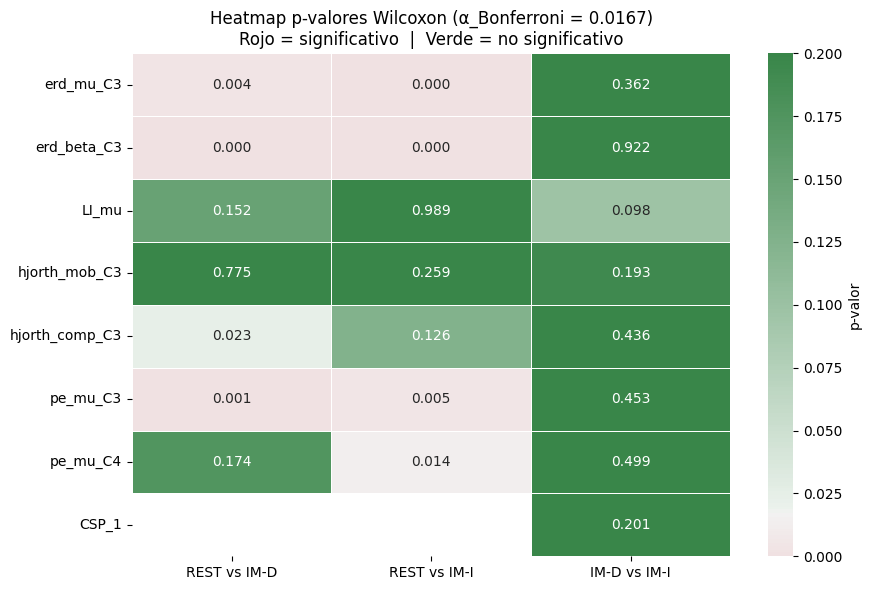


Resumen de hipótesis:
  H1 (PSD mu C3 vs C4, IM-D)   : p = 0.1304  — No rechaza H₀
  H2 (Hjorth mob C3, Friedman)  : p = 0.5774  — No rechaza H₀
  H3 (PE C4, REST vs IM-I)      : p = 0.0137  ✓ Rechaza H₀
  H4 (CSP_1, IM-D vs IM-I)     : p = 0.2013  — No rechaza H₀


In [22]:
# ============================================================
# HEATMAP DE P-VALORES — todos los índices, todos los pares
# ============================================================

vars_heat = [
    'erd_mu_C3', 'erd_beta_C3', 'LI_mu',
    'hjorth_mob_C3', 'hjorth_comp_C3',
    'pe_mu_C3', 'pe_mu_C4',
    'CSP_1'
]
vars_heat = [v for v in vars_heat if v in df_final.columns]

pares_heat = [
    ('REST', 'IM-D'), ('REST', 'IM-I'), ('IM-D', 'IM-I')
]
alpha_bon_heat = ALPHA / len(pares_heat)

p_matrix = np.zeros((len(vars_heat), len(pares_heat)))

for i, var in enumerate(vars_heat):
    for j, (c1, c2) in enumerate(pares_heat):
        d1 = df_final[df_final['condicion']==c1][var].dropna().values
        d2 = df_final[df_final['condicion']==c2][var].dropna().values
        n  = min(len(d1), len(d2))
        try:
            _, p = stats.wilcoxon(d1[:n], d2[:n])
        except Exception:
            p = 1.0
        p_matrix[i, j] = p

etiquetas_x = [f'{c1} vs {c2}' for c1, c2 in pares_heat]
df_heat = pd.DataFrame(p_matrix, index=vars_heat, columns=etiquetas_x)

fig, ax = plt.subplots(figsize=(9, 6))
cmap = sns.diverging_palette(10, 133, as_cmap=True)
sns.heatmap(df_heat, annot=True, fmt='.3f',
            cmap=cmap, center=alpha_bon_heat,
            vmin=0, vmax=0.2,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'p-valor'})
ax.set_title(
    f'Heatmap p-valores Wilcoxon (α_Bonferroni = {alpha_bon_heat:.4f})\n'
    'Rojo = significativo  |  Verde = no significativo',
    fontsize=12
)
plt.tight_layout()
plt.savefig('heatmap_pvalores_P2.png', dpi=150)
plt.show()

print("\nResumen de hipótesis:")
print(f"  H1 (PSD mu C3 vs C4, IM-D)   : p = {p_h1:.4f}  "
      f"{'✓ Rechaza H₀' if p_h1 < ALPHA else '— No rechaza H₀'}")
print(f"  H2 (Hjorth mob C3, Friedman)  : p = {p_h2:.4f}  "
      f"{'✓ Rechaza H₀' if p_h2 < ALPHA else '— No rechaza H₀'}")
print(f"  H3 (PE C4, REST vs IM-I)      : p = {p_h3:.4f}  "
      f"{'✓ Rechaza H₀' if p_h3 < ALPHA else '— No rechaza H₀'}")
if 'CSP_1' in df_final.columns:
    print(f"  H4 (CSP_1, IM-D vs IM-I)     : p = {p_h4:.4f}  "
          f"{'✓ Rechaza H₀' if p_h4 < ALPHA else '— No rechaza H₀'}")


------
------
------

 Preparación de features para clasificación

In [23]:
# ============================================================
# BLOQUE 5 — CLASIFICACIÓN SUPERVISADA
# Condiciones: REST, IM-D, IM-I (3 clases)
# ============================================================

from sklearn.preprocessing     import StandardScaler, LabelEncoder
from sklearn.model_selection   import StratifiedKFold, cross_val_predict
from sklearn.pipeline          import Pipeline
from sklearn.svm               import SVC
from sklearn.metrics           import (confusion_matrix, accuracy_score,
                                        classification_report,
                                        ConfusionMatrixDisplay)
from sklearn.neural_network    import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
warnings.filterwarnings('ignore')

# ── Selección de features ────────────────────────────────────
# Usamos los índices que mostraron mayor separación en el Bloque 4

FEATURES = [
    # PSD (P1)
    'erd_mu_C3', 'erd_mu_C4', 'erd_beta_C3', 'erd_beta_C4', 'LI_mu',
    # Hjorth (P2)
    'hjorth_act_C3', 'hjorth_mob_C3', 'hjorth_comp_C3',
    'hjorth_act_C4', 'hjorth_mob_C4', 'hjorth_comp_C4',
    # Entropía de permutación (P2)
    'pe_mu_C3', 'pe_mu_C4', 'pe_beta_C3', 'pe_beta_C4',
    # CSP (P2) — solo disponible en IM-D e IM-I; NaN en REST
    'CSP_1', 'CSP_2', 'CSP_3', 'CSP_4', 'CSP_5', 'CSP_6',
]

FEATURES = [f for f in FEATURES if f in df_final.columns]

# ── Filtrar solo las 3 condiciones del P2 ───────────────────
df_clf = df_final[df_final['condicion'].isin(['REST', 'IM-D', 'IM-I'])].copy()

# Para REST los CSP son NaN → rellenar con 0
# (REST no participó en el ajuste CSP, su log-varianza basal ≈ 0)
csp_cols = [c for c in FEATURES if c.startswith('CSP_')]
df_clf[csp_cols] = df_clf[csp_cols].fillna(0)

# Eliminar filas con NaN en otras columnas
df_clf = df_clf.dropna(subset=FEATURES)

X = df_clf[FEATURES].values
y = LabelEncoder().fit_transform(df_clf['condicion'].values)
# REST=0, IM-D=1, IM-I=2  (orden alfabético del LabelEncoder)

le = LabelEncoder().fit(df_clf['condicion'].values)
class_names = le.classes_

print(f"Features usados  : {len(FEATURES)}")
print(f"Muestras totales : {len(X)}")
print(f"Clases           : {class_names}")
print(f"Distribución     :")
for nombre, cod in zip(class_names, range(3)):
    print(f"  {nombre}: {(y == cod).sum()} épocas")

Features usados  : 21
Muestras totales : 424
Clases           : ['IM-D' 'IM-I' 'REST']
Distribución     :
  IM-D: 71 épocas
  IM-I: 73 épocas
  REST: 280 épocas


In [24]:
# ============================================================
# Función reutilizable para matrices de confusión
# ============================================================

def plot_confusion(y_true, y_pred, titulo, class_names, ax):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'{titulo}\nAccuracy = {acc:.3f}', fontsize=11)


def evaluar_modelo(nombre, pipeline, X, y, cv, class_names):
    """
    Corre cross_val_predict con k-fold estratificado.
    Retorna accuracy promedio y predicciones.
    """
    y_pred = cross_val_predict(pipeline, X, y, cv=cv)
    acc    = accuracy_score(y, y_pred)
    print(f"\n{nombre}")
    print(f"  Accuracy k-fold: {acc:.4f}  ({acc*100:.1f}%)")
    print(classification_report(y, y_pred,
                                  target_names=class_names,
                                  digits=3))
    return acc, y_pred


print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


 Estrategia k-fold y modelos SVM + XGBoost


SVM Lineal
  Accuracy k-fold: 0.8538  (85.4%)
              precision    recall  f1-score   support

        IM-D      0.565     0.549     0.557        71
        IM-I      0.573     0.589     0.581        73
        REST      1.000     1.000     1.000       280

    accuracy                          0.854       424
   macro avg      0.713     0.713     0.713       424
weighted avg      0.854     0.854     0.854       424


SVM RBF
  Accuracy k-fold: 0.8467  (84.7%)
              precision    recall  f1-score   support

        IM-D      0.541     0.563     0.552        71
        IM-I      0.557     0.534     0.545        73
        REST      1.000     1.000     1.000       280

    accuracy                          0.847       424
   macro avg      0.699     0.699     0.699       424
weighted avg      0.847     0.847     0.847       424


XGBoost
  Accuracy k-fold: 0.8656  (86.6%)
              precision    recall  f1-score   support

        IM-D      0.600     0.592     0.596     

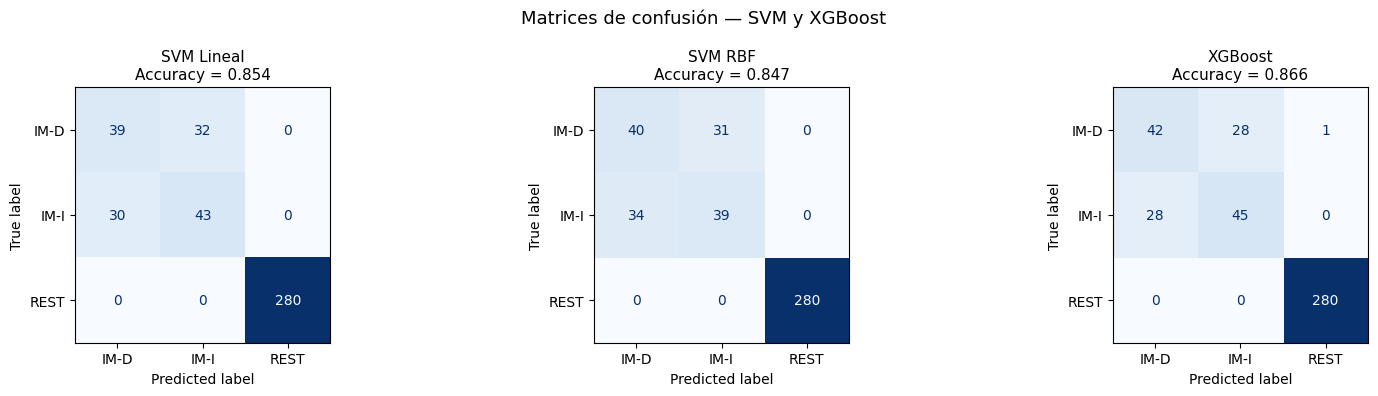

In [25]:
# ============================================================
# K-FOLD ESTRATIFICADO k=5
# Modelos: SVM lineal, SVM RBF, XGBoost
# ============================================================

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = {}   # {nombre: (accuracy, y_pred)}

# ── SVM Lineal ───────────────────────────────────────────────
pipe_svm_lin = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(kernel='linear', C=1.0,
                   random_state=42, class_weight='balanced'))
])
acc, ypred = evaluar_modelo('SVM Lineal', pipe_svm_lin, X, y, CV, class_names)
resultados['SVM Lineal'] = (acc, ypred)


# ── SVM RBF ──────────────────────────────────────────────────
pipe_svm_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(kernel='rbf', C=10.0, gamma='scale',
                   random_state=42, class_weight='balanced'))
])
acc, ypred = evaluar_modelo('SVM RBF', pipe_svm_rbf, X, y, CV, class_names)
resultados['SVM RBF'] = (acc, ypred)


# ── XGBoost ──────────────────────────────────────────────────
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    xgb.XGBClassifier(
                   n_estimators=200, max_depth=4,
                   learning_rate=0.05, subsample=0.8,
                   use_label_encoder=False,
                   eval_metric='mlogloss',
                   random_state=42, verbosity=0))
])
acc, ypred = evaluar_modelo('XGBoost', pipe_xgb, X, y, CV, class_names)
resultados['XGBoost'] = (acc, ypred)


# ── Matrices de confusión ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (nombre, (acc, ypred)) in zip(axes,
        {k: v for k, v in resultados.items()
         if k in ['SVM Lineal', 'SVM RBF', 'XGBoost']}.items()):
    plot_confusion(y, ypred, nombre, class_names, ax)

plt.suptitle('Matrices de confusión — SVM y XGBoost', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_svm_xgb.png', dpi=150)
plt.show()

 Red neuronal MLP

In [26]:
# ============================================================
# RED NEURONAL 1 — MLP (Perceptrón Multicapa)
# 3 capas densas con Dropout
# ============================================================

def crear_mlp(n_features, n_clases):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(n_clases, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


# K-fold manual para Keras (cross_val_predict no es compatible directo)
scaler_mlp = StandardScaler()
y_pred_mlp = np.zeros(len(y), dtype=int)

for fold, (train_idx, test_idx) in enumerate(CV.split(X, y)):
    X_tr = scaler_mlp.fit_transform(X[train_idx])
    X_te = scaler_mlp.transform(X[test_idx])
    y_tr = y[train_idx]

    model = crear_mlp(X_tr.shape[1], len(class_names))
    model.fit(X_tr, y_tr,
              epochs=80, batch_size=32,
              verbose=0,
              validation_split=0.1)

    probs = model.predict(X_te, verbose=0)
    y_pred_mlp[test_idx] = np.argmax(probs, axis=1)

acc_mlp = accuracy_score(y, y_pred_mlp)
resultados['MLP'] = (acc_mlp, y_pred_mlp)

print("MLP")
print(f"  Accuracy k-fold: {acc_mlp:.4f}  ({acc_mlp*100:.1f}%)")
print(classification_report(y, y_pred_mlp,
                              target_names=class_names, digits=3))

MLP
  Accuracy k-fold: 0.8608  (86.1%)
              precision    recall  f1-score   support

        IM-D      0.579     0.620     0.599        71
        IM-I      0.603     0.562     0.582        73
        REST      1.000     1.000     1.000       280

    accuracy                          0.861       424
   macro avg      0.727     0.727     0.727       424
weighted avg      0.861     0.861     0.861       424



Red neuronal Conv1D

In [ ]:
# ============================================================
# RED NEURONAL 2 — Conv1D
# Trata cada feature como una secuencia temporal de 1 paso
# Captura patrones locales entre features adyacentes
# ============================================================

def crear_conv1d(n_features, n_clases):
    model = keras.Sequential([
        layers.Input(shape=(n_features, 1)),
        layers.Conv1D(filters=32, kernel_size=3,
                      activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv1D(filters=64, kernel_size=3,
                      activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(n_clases, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


scaler_conv = StandardScaler()
y_pred_conv = np.zeros(len(y), dtype=int)

for fold, (train_idx, test_idx) in enumerate(CV.split(X, y)):
    X_tr = scaler_conv.fit_transform(X[train_idx])
    X_te = scaler_conv.transform(X[test_idx])

    # Reshape para Conv1D: (muestras, features, 1)
    X_tr_3d = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
    X_te_3d = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)

    model = crear_conv1d(X_tr.shape[1], len(class_names))
    model.fit(X_tr_3d, y[train_idx],
              epochs=80, batch_size=32,
              verbose=0,
              validation_split=0.1)

    probs = model.predict(X_te_3d, verbose=0)
    y_pred_conv[test_idx] = np.argmax(probs, axis=1)

acc_conv = accuracy_score(y, y_pred_conv)
resultados['Conv1D'] = (acc_conv, y_pred_conv)

print("Conv1D")
print(f"  Accuracy k-fold: {acc_conv:.4f}  ({acc_conv*100:.1f}%)")
print(classification_report(y, y_pred_conv,
                              target_names=class_names, digits=3))

Red neuronal EEGNet simplificado

In [ ]:
# ============================================================
# RED NEURONAL 3 — EEGNet simplificado
# Arquitectura compacta especializada en BCI
# Referencia: Lawhern et al. (2018)
# Adaptada para entrada de features (no señal cruda)
# ============================================================

def crear_eegnet_simple(n_features, n_clases):
    inputs = keras.Input(shape=(n_features, 1))

    # Bloque 1: convolución temporal
    x = layers.Conv1D(8, kernel_size=5,
                       padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)

    # Bloque 2: convolución depthwise (simula filtros espaciales)
    x = layers.DepthwiseConv1D(kernel_size=3,
                                 padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling1D(pool_size=2)(x)
    x = layers.Dropout(0.25)(x)

    # Bloque 3: convolución separable
    x = layers.SeparableConv1D(16, kernel_size=3,
                                 padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(n_clases, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


scaler_eeg = StandardScaler()
y_pred_eeg = np.zeros(len(y), dtype=int)

for fold, (train_idx, test_idx) in enumerate(CV.split(X, y)):
    X_tr = scaler_eeg.fit_transform(X[train_idx])
    X_te = scaler_eeg.transform(X[test_idx])

    X_tr_3d = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
    X_te_3d = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)

    model = crear_eegnet_simple(X_tr.shape[1], len(class_names))
    model.fit(X_tr_3d, y[train_idx],
              epochs=80, batch_size=32,
              verbose=0,
              validation_split=0.1)

    probs = model.predict(X_te_3d, verbose=0)
    y_pred_eeg[test_idx] = np.argmax(probs, axis=1)

acc_eeg = accuracy_score(y, y_pred_eeg)
resultados['EEGNet'] = (acc_eeg, y_pred_eeg)

print("EEGNet simplificado")
print(f"  Accuracy k-fold: {acc_eeg:.4f}  ({acc_eeg*100:.1f}%)")
print(classification_report(y, y_pred_eeg,
                              target_names=class_names, digits=3))

Matrices de confusión redes neuronales

In [ ]:
# ============================================================
# MATRICES DE CONFUSIÓN — Redes neuronales
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, nombre in zip(axes, ['MLP', 'Conv1D', 'EEGNet']):
    acc, ypred = resultados[nombre]
    plot_confusion(y, ypred, nombre, class_names, ax)

plt.suptitle('Matrices de confusión — Redes Neuronales', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_redes.png', dpi=150)
plt.show()

 Comparación final de todos los modelos

In [ ]:
# ============================================================
# COMPARACIÓN FINAL — todos los modelos vs nivel de azar
# H5: accuracy > 33.3%
# ============================================================

UMBRAL_AZAR = 1 / len(class_names)   # 0.333 para 3 clases

nombres  = list(resultados.keys())
accs     = [resultados[n][0] for n in nombres]

fig, ax = plt.subplots(figsize=(10, 5))
colores_bar = ['#2196F3' if a > UMBRAL_AZAR else '#EF5350' for a in accs]
bars = ax.bar(nombres, accs, color=colores_bar,
               edgecolor='black', width=0.5)

# Línea de azar
ax.axhline(UMBRAL_AZAR, color='red', linestyle='--',
            linewidth=2, label=f'Nivel de azar ({UMBRAL_AZAR:.1%})')

# Etiquetas de valor
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, 1.0)
ax.set_ylabel('Accuracy (k-fold k=5)')
ax.set_title('Comparación de modelos — Accuracy vs nivel de azar teórico\n'
             '(azul = supera el azar  |  rojo = no supera el azar)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150)
plt.show()

# ── Resumen en tabla ─────────────────────────────────────────
print("\n" + "=" * 55)
print("RESUMEN FINAL — H5: accuracy > 33.3%")
print("=" * 55)
print(f"{'Modelo':<15} {'Accuracy':>10} {'> Azar?':>10}")
print("-" * 40)
for nombre, acc in zip(nombres, accs):
    supera = "✓ Sí" if acc > UMBRAL_AZAR else "✗ No"
    print(f"{nombre:<15} {acc:>10.4f} {supera:>10}")
print("-" * 40)
print(f"{'Nivel de azar':<15} {UMBRAL_AZAR:>10.4f}")
print("=" * 55)

mejor = nombres[np.argmax(accs)]
print(f"\nMejor modelo: {mejor} ({max(accs):.4f})")
print(f"H5: {'✓ Se rechaza H₀ — el clasificador supera el azar' if max(accs) > UMBRAL_AZAR else '✗ No se rechaza H₀'}")

# **REFERENCIAS**

1. Ramoser, H., Muller-Gerking, J., & Pfurtscheller, G. (2000). Optimal spatial filtering of single trial EEG during imagined hand movement. IEEE Transactions on Rehabilitation Engineering, 8(4), 441–446. https://doi.org/10.1109/86.895946

2. Hjorth, B. (1970). EEG analysis based on time domain properties. Electroencephalography And Clinical Neurophysiology, 29(3), 306-310. https://doi.org/10.1016/0013-4694(70)90143-4

2. Rahman, M. K. M., & Joadder, M. A. M. (2020). A space-frequency localized approach of spatial filtering for motor imagery classification. Health information science and systems, 8(1), 15. https://doi.org/10.1007/s13755-020-00106-8

4. Bandt, C., & Pompe, B. (2002). Permutation Entropy: A Natural Complexity Measure for Time Series. Physical Review Letters, 88(17), 174102. https://doi.org/10.1103/physrevlett.88.174102

4. Li, J., Yan, J., Liu, X., & Ouyang, G. (2014). Using Permutation Entropy to Measure the Changes in EEG Signals During Absence Seizures. Entropy, 16(6), 3049-3061. https://doi.org/10.3390/e16063049

5.
